# QFT for Periodic Signals

In [1]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *
from qiskit.circuit.library import StatePreparation, QFT

import numpy as np
import matplotlib.pyplot as plt

## Visualizatin function

In [17]:
def qplot(x):
    return x.draw('mpl', scale=0.7, fold=-1, cregbundle=True, initial_state=True)

# Periodic Function

$$x = A \text{sin}(2\pi f t)$$
- $A$: amplitude
- $f$: frequency

In [3]:
# sampling rate
srate = 256 # 256 = 2^8

# time interval
t = np.arange(0,1, 1/srate)

# siganl: A = 5, f = 3
ampl = 5
f = 3
x = ampl * np.sin(2*np.pi * f * t )

## Visualization of Periodic function

Text(0, 0.5, 'x(t)')

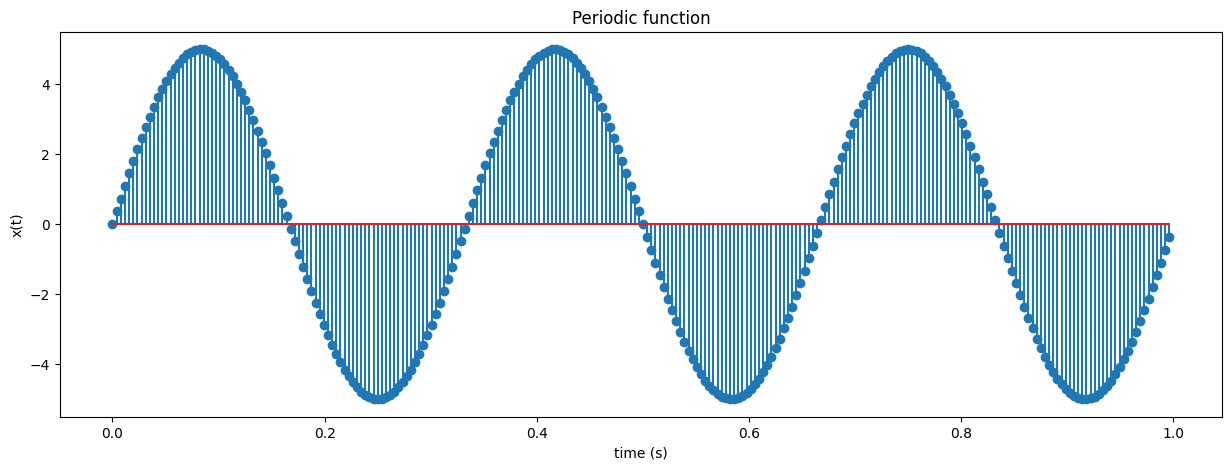

In [5]:
plt.figure(figsize = (15,5))
plt.stem(t,x)
plt.title('Periodic function')
plt.xlabel('time (s)')
plt.ylabel('x(t)')

# Normalization of Periodic Function

In [9]:
x_norm = x/np.linalg.norm(x)

x_norm @ x_norm.T

np.float64(0.9999999999999999)

## QFT for Periodic Signal

In [12]:
# Number of qubit for QFT
n = int(np.log2(srate))
n

8

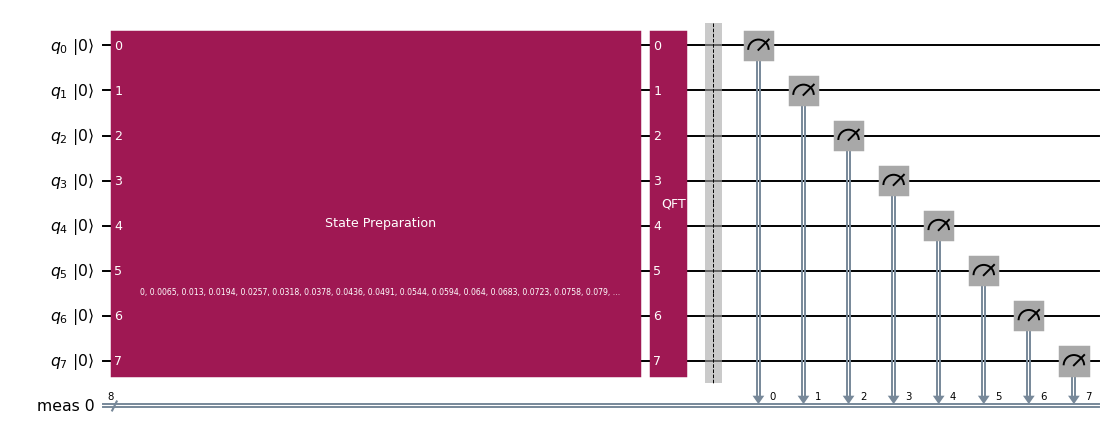

In [20]:
qc = QuantumCircuit(n)

# Preparation of x_norm
qc.append(StatePreparation(x_norm), [i for i in range(n)])

# Apply QFT
qc.append(QFT(n), [i  for i in range(n)])

# Measurement
qc.measure_all()

qplot(qc)



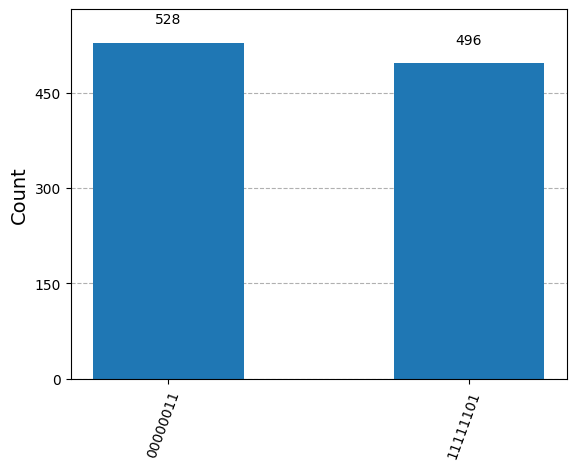

In [21]:
backend = QasmSimulator()
t_qc = transpile(qc, backend)
job = backend.run(t_qc)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

## Classical Fast Fourier Transform (FFT)

In [22]:
X = np.fft.fft(x)

In [24]:
np.abs(X)

array([8.59545286e-15, 1.92273778e-14, 6.37010929e-14, 6.40000000e+02,
       7.78905820e-14, 4.16604333e-14, 3.76498808e-14, 2.08671183e-14,
       2.28551040e-14, 1.23193071e-14, 2.06765323e-14, 1.48948859e-14,
       2.68264483e-14, 1.92029199e-14, 2.29907782e-14, 1.48482693e-14,
       2.49582948e-14, 3.09809296e-14, 2.18922798e-14, 4.41855322e-14,
       9.11515544e-15, 1.20330893e-14, 1.49615773e-14, 6.31081283e-15,
       3.06959897e-14, 2.09017678e-14, 2.95689077e-14, 2.87955594e-14,
       9.96986897e-15, 8.89674020e-14, 1.15201348e-14, 2.10830960e-14,
       2.44152777e-14, 1.85859944e-14, 2.03504721e-14, 3.34931136e-14,
       1.18088425e-14, 2.21564190e-14, 3.91805555e-14, 3.40384865e-14,
       5.89002153e-14, 6.51505157e-14, 4.82546204e-14, 6.31463685e-14,
       3.99683968e-14, 3.31915448e-15, 2.80567236e-14, 2.86628855e-14,
       5.49350607e-14, 4.27663694e-14, 6.45608692e-14, 5.32363470e-14,
       5.73869949e-14, 3.34759853e-14, 2.23186471e-14, 2.21526737e-14,
      

Text(0, 0.5, 'X')

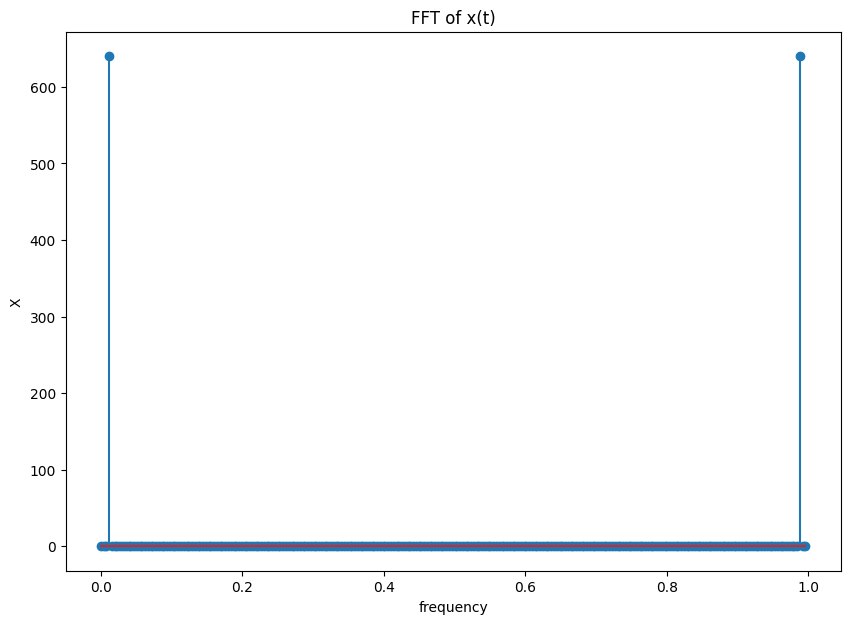

In [23]:
plt.figure(figsize = (10,7))
plt.stem(t, np.abs(X))
plt.title('FFT of x(t)')
plt.xlabel('frequency')
plt.ylabel('X')